In [1]:
%config Completer.use_jedi = False

In [1]:
# jupyter notebook 전체화면으로 변경  
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [1]:
# load module
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import copy
import warnings
import torch
import optuna
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorboard as tb 
import pytorch_lightning as pl


from pathlib import Path
from pytorch_lightning.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import TensorBoardLogger

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet , EncoderNormalizer , GroupNormalizer
from pytorch_forecasting.metrics import SMAPE, PoissonLoss, QuantileLoss
#from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters
from IPython.core.display import HTML

import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings("ignore")  # avoid printing out absolute paths
plt.rcParams['font.family'] = 'NanumGothic'
#plt.rcParams['font.sans-serif'] = ['NanumGothic.ttf', 'sans-serif']

from my_funs import *

/home/nplab/.local/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/nplab/.local/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefIlEENS2_8optionalINS2_10ScalarTypeEEENS5_INS2_6LayoutEEENS5_INS2_6DeviceEEENS5_IbEENS5_INS2_12MemoryFormatEEE
  warn(f"Failed to load image Python extension: {e}")
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.1.36ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/home/nplab/.local/lib/python3.8/site-packages/pkg_resources/__init__.py:116: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will n

In [3]:
result_df = pd.read_csv('ewma_test.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'ewma_test.csv'

강남동 f1_score 0.0
강남동 f1_score 0.0
강남동 f1_score 0.06424870466321243
강남동 f1_score 0.07207207207207207
강남동 f1_score 0.07155025553662692
강남동 f1_score 0.15954415954415954
강남동 f1_score 0.1353965183752418
강남동 f1_score 0.1190893169877408
강남동 f1_score 0.1216457960644007
강남동 f1_score 0.13580246913580246
강남동 f1_score 0.14893617021276595
강남동 f1_score 0.07629427792915532
강남동 f1_score 0.13255360623781676
강남동 f1_score 0.14285714285714285
강남동 f1_score 0.08243727598566307
강남동 f1_score 0.14847161572052403
강남동 f1_score 0.11790393013100438
강남동 f1_score 0.0348432055749129
강남동 f1_score 0.0
강남동 f1_score 0.08181818181818182


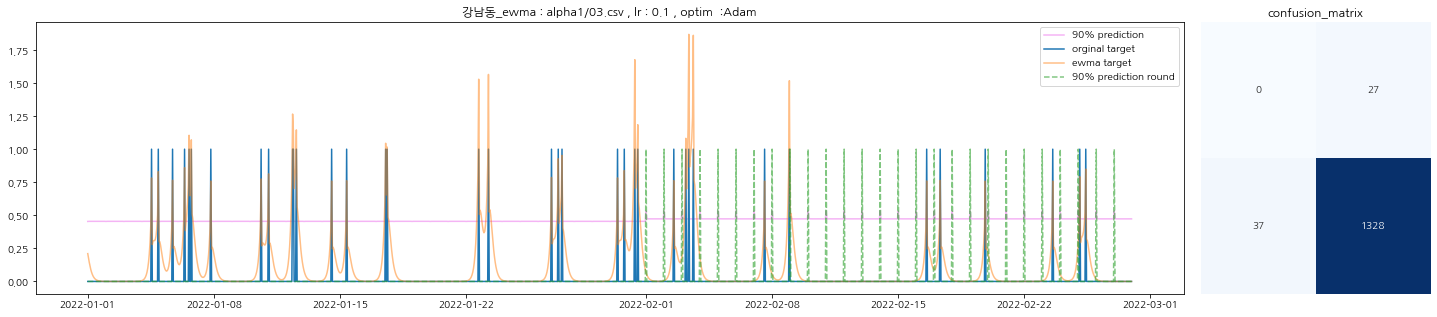

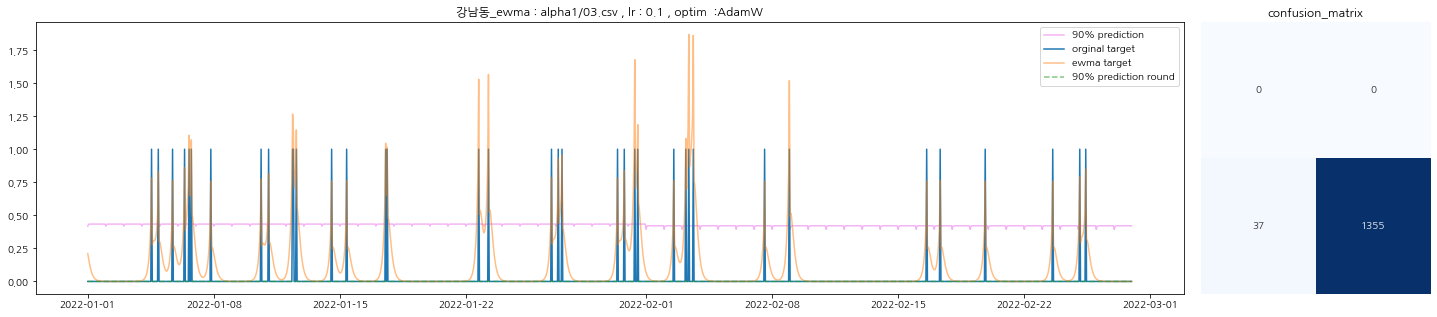

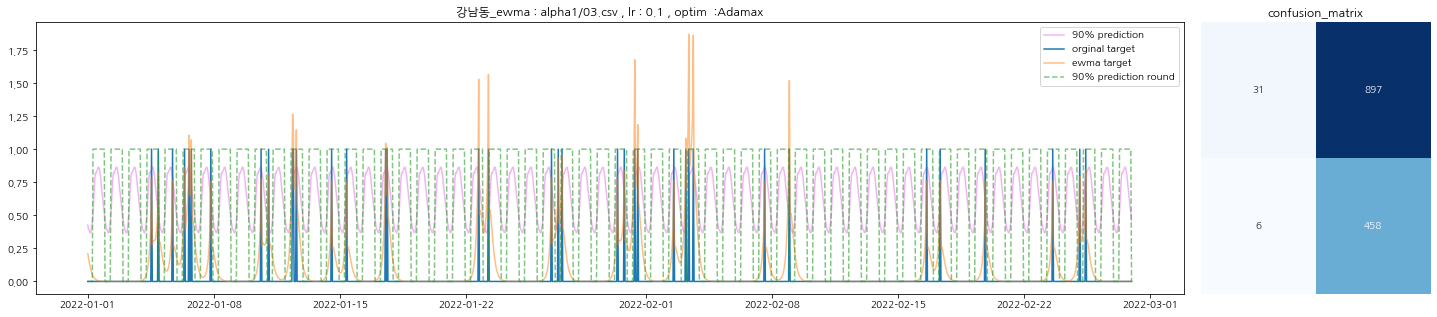

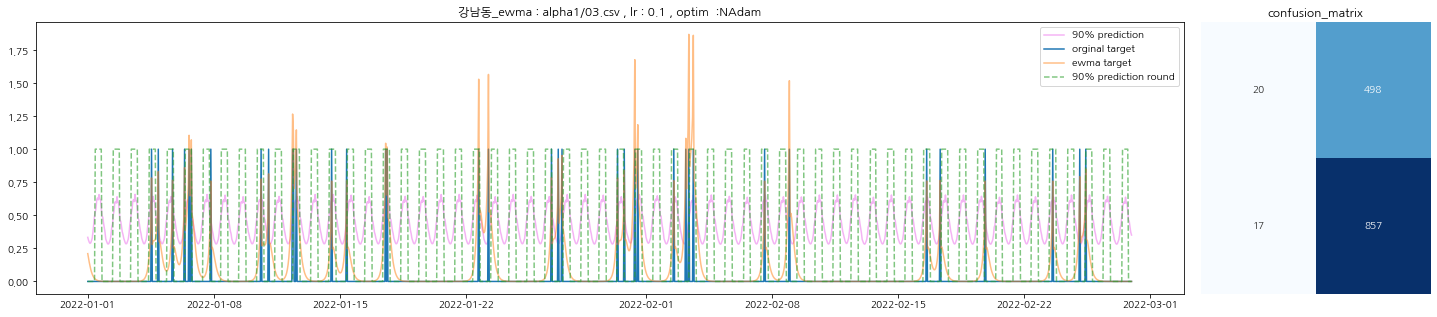

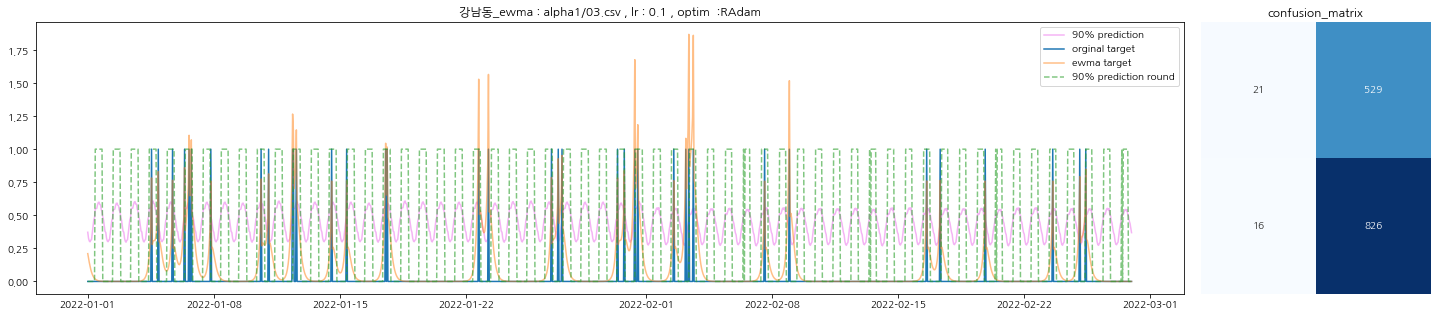

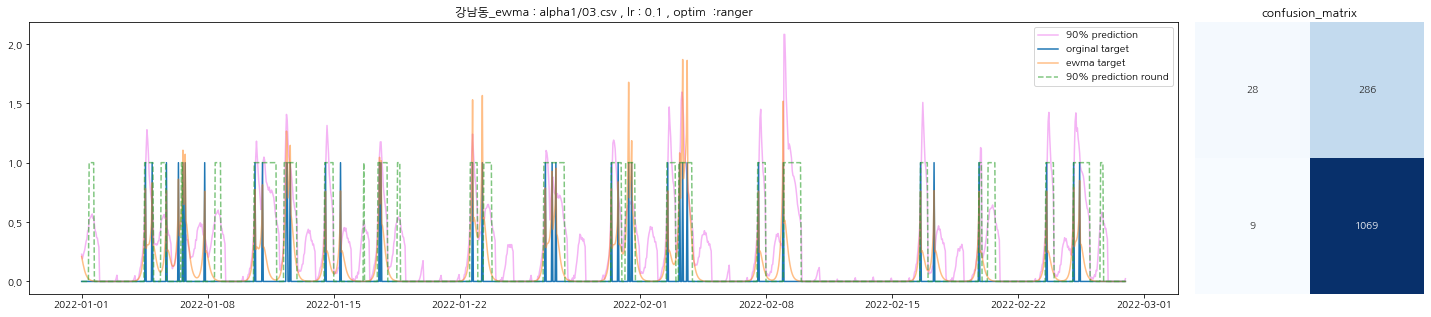

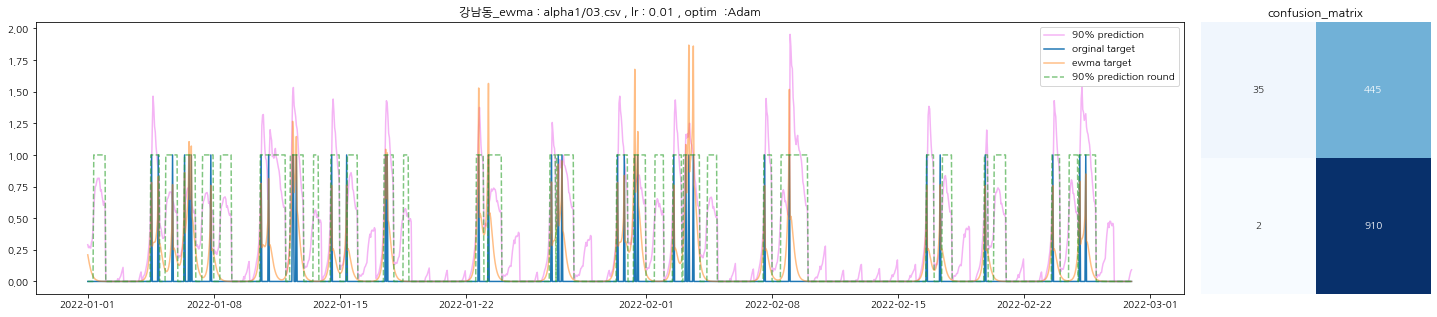

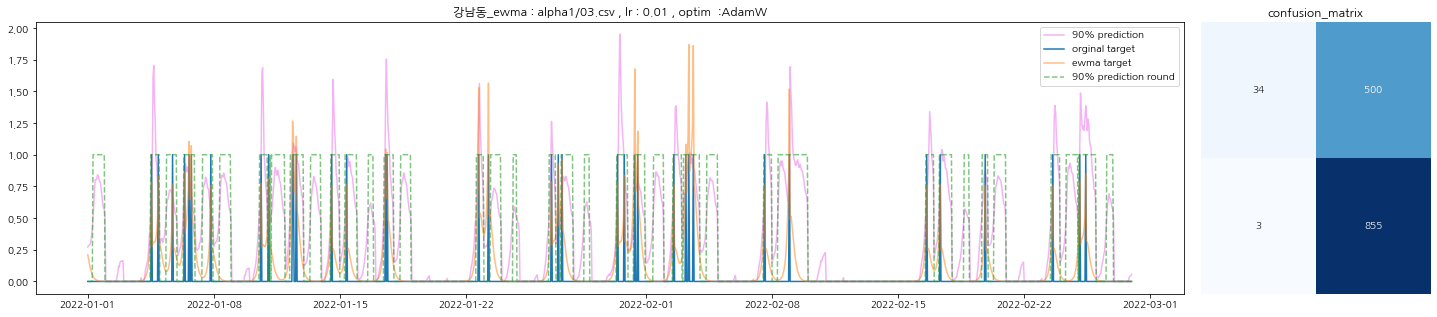

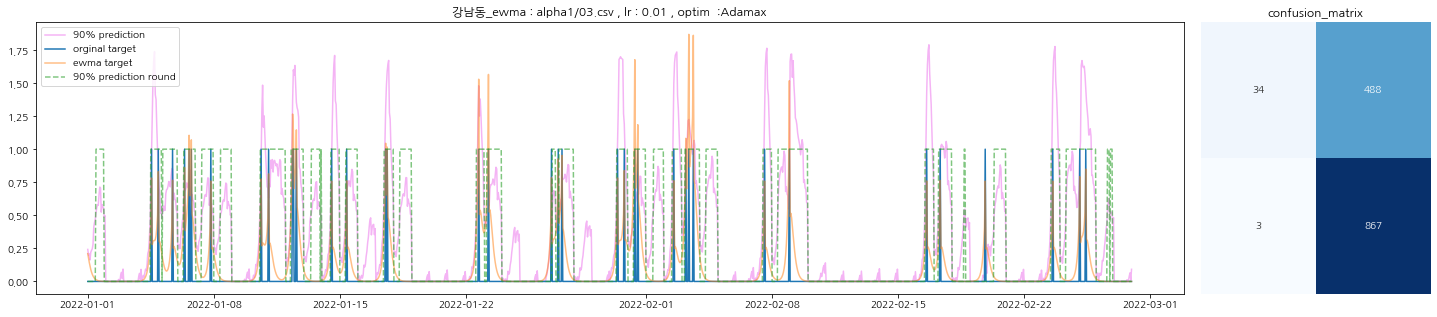

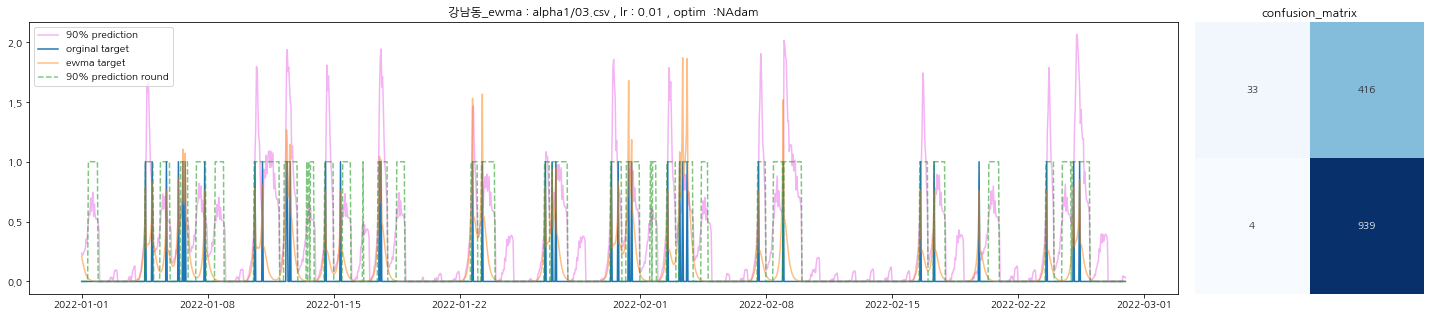

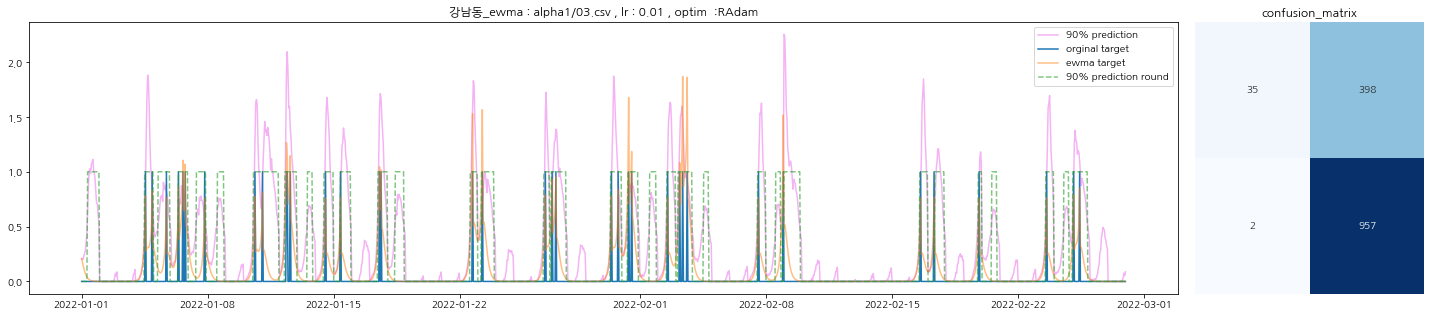

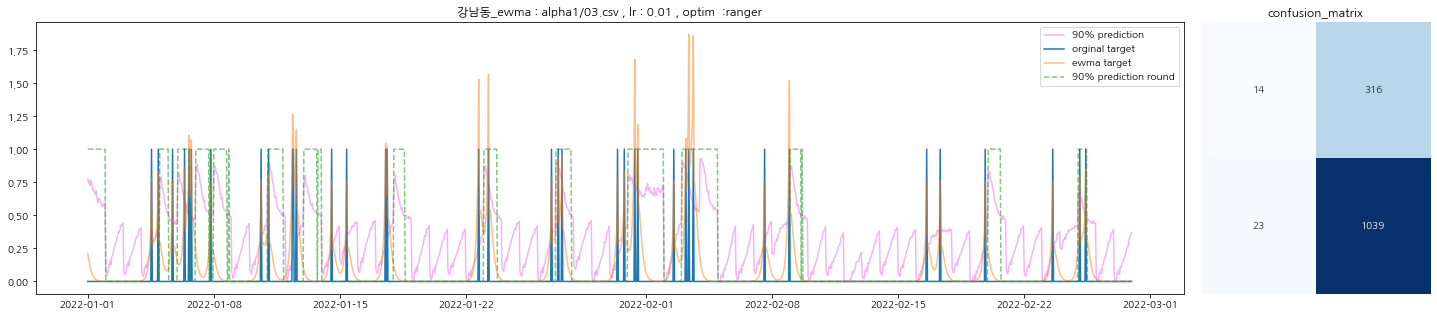

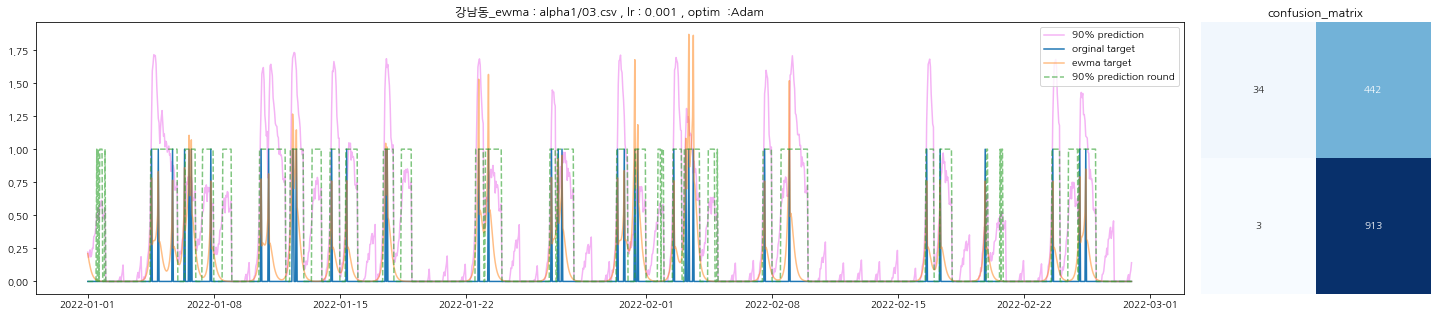

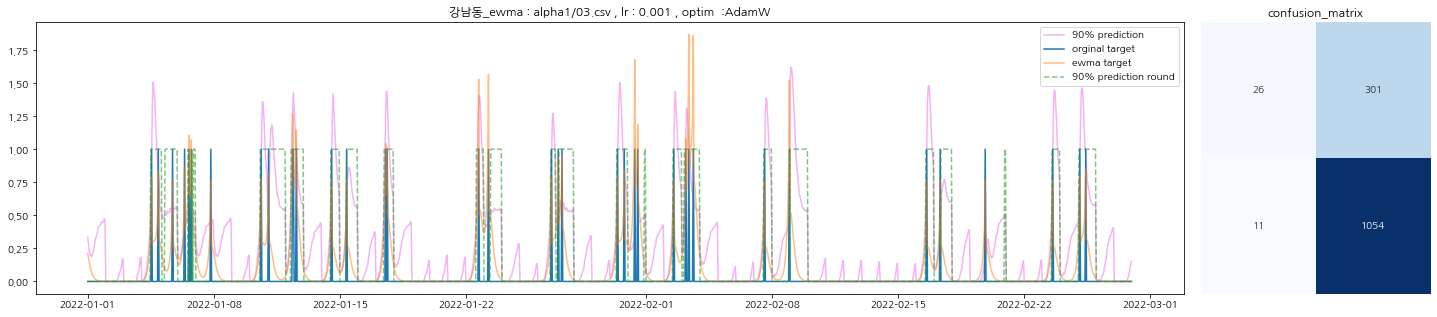

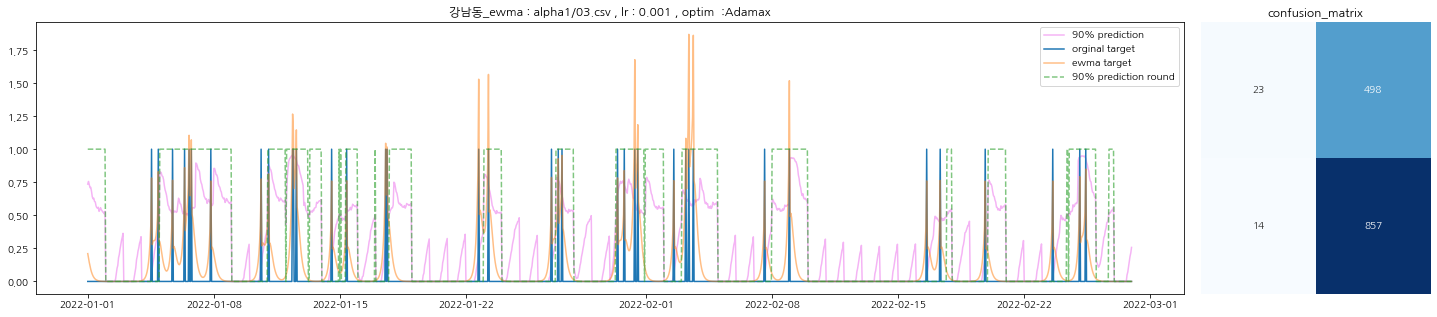

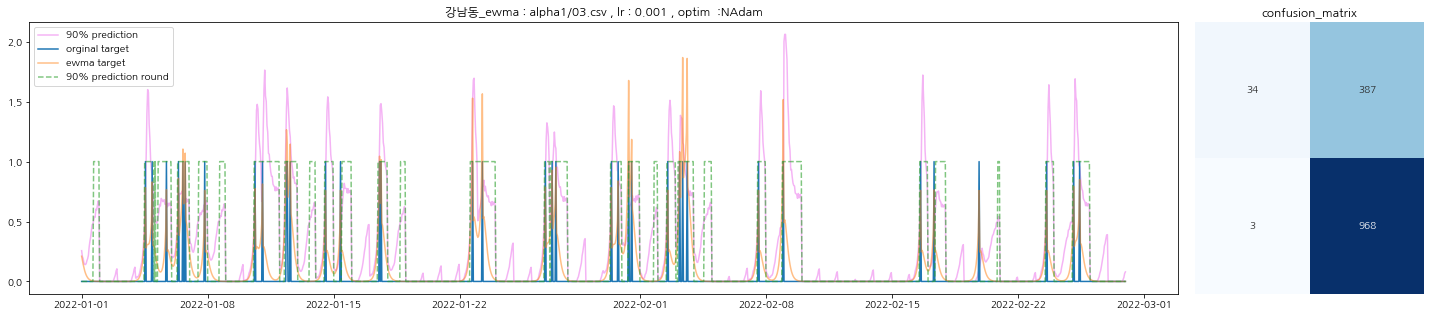

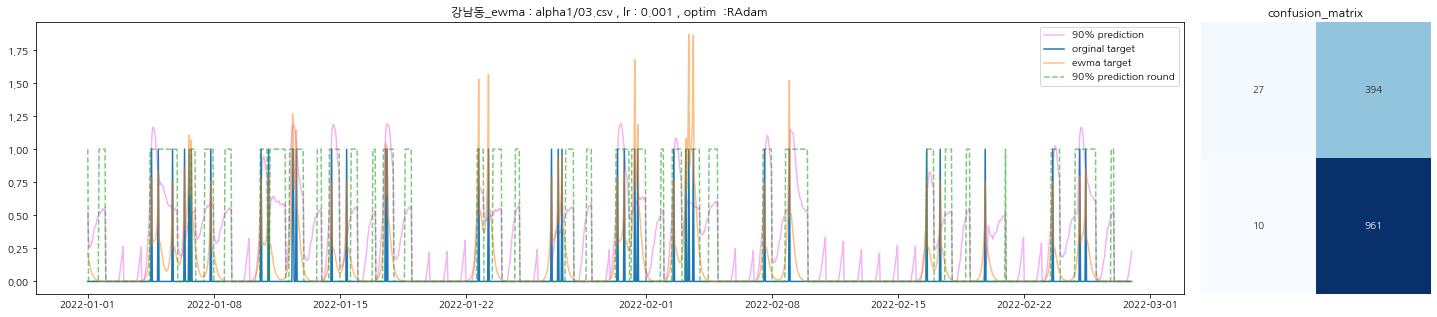

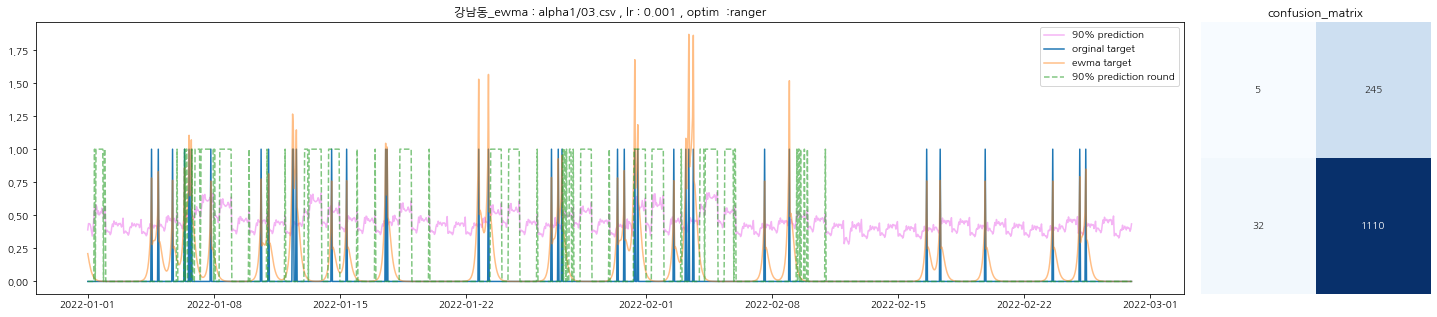

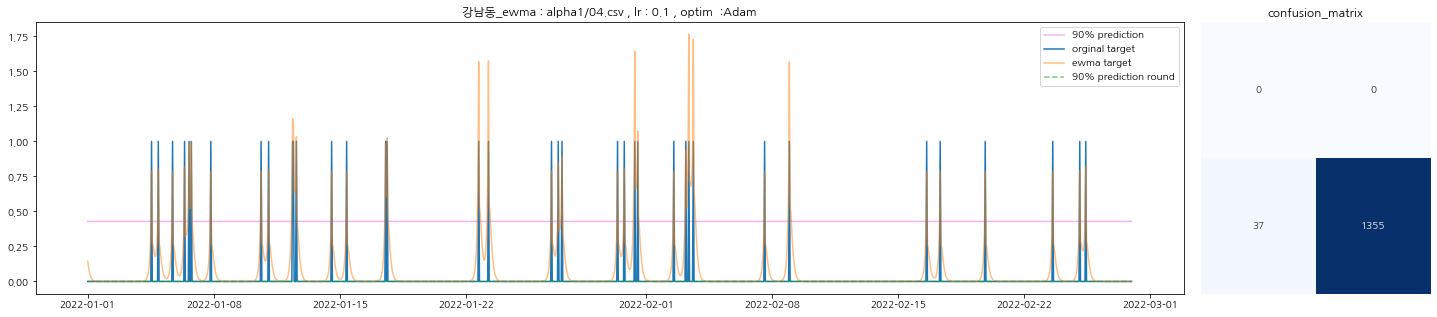

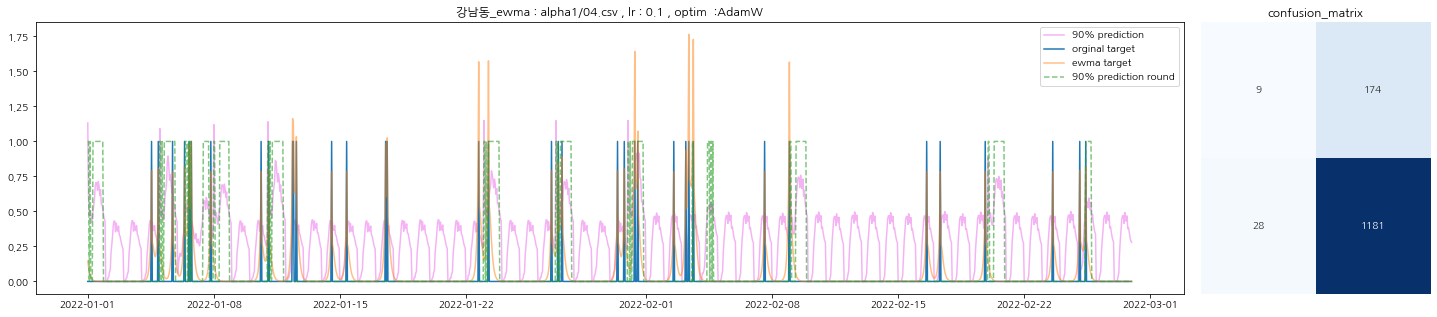

In [4]:
for idx in result_df.index[:20]:
    fun = result_df['fun'].loc[idx]
    factor = result_df['factor'].loc[idx]
    ewma = result_df['funs'].loc[idx]
    model_ckpt = result_df['model_ckpt'].loc[idx]
    train_data = data_processing('../../train.csv')
    test_data = data_processing('../../test.csv')
    training = get_training(train_data,24, 24*7)
    tft = TemporalFusionTransformer.load_from_checkpoint(model_ckpt)
    confusion_matrix_plot(training, tft,tes_data, '강남동' , f' ewma : {ewma} // factor {factor}')
    
